In [15]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

In [21]:
batDict = pickle.load(open(r'../data/batDict.pkl', 'rb'))


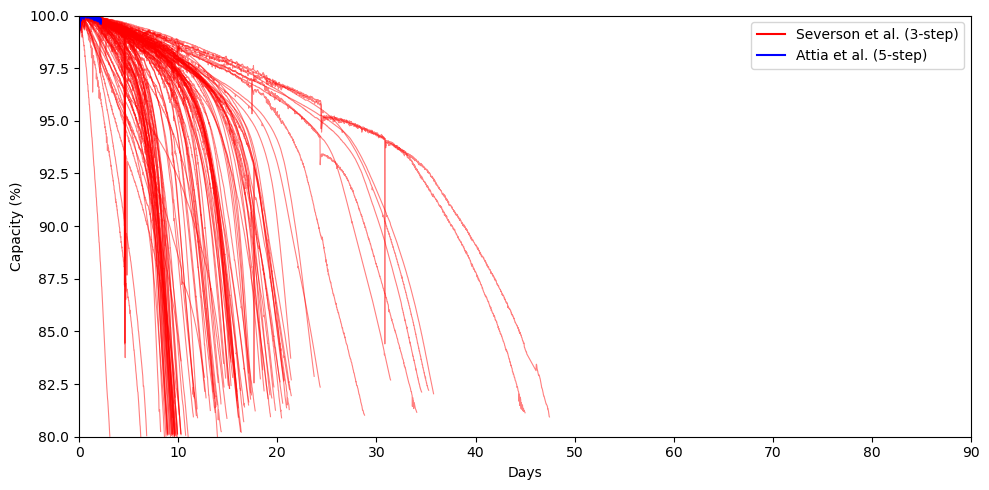

In [16]:
DISCHARGE_MIN = 1.1 / 4 * 60   # 4C discharge → ~16.5 minutes

fig, ax = plt.subplots(figsize=(10, 5))

for key in batDict:
    cell        = batDict[key]
    qd          = cell['summary']['QD']
    ct          = cell['summary']['chargetime']
    cycle_time  = ct + DISCHARGE_MIN          # total time per cycle in minutes
    days        = np.cumsum(cycle_time) / 60 / 24
    cap_pct     = qd / np.max(qd) * 100
    mask        = cap_pct >= 80
    color       = 'blue' if key.startswith('b4') else 'red'
    ax.plot(days[mask], cap_pct[mask], color=color, alpha=0.5, linewidth=0.8)

ax.set_xlabel('Days')
ax.set_ylabel('Capacity (%)')
ax.set_xlim(0, 90)
ax.set_ylim(80, 100)

from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0], [0], color='red',  label='Severson et al. (3-step)'),
    Line2D([0], [0], color='blue', label='Attia et al. (5-step)')
])
plt.tight_layout()
plt.show()

In [17]:
cell = batDict['b1c0']
ct = cell['summary']['chargetime']
days = np.cumsum(ct + DISCHARGE_MIN) / 60 / 24
print(f"cycles: {len(ct)}, max days: {days[-1]:.1f}")

cycles: 1851, max days: 38.6


In [18]:
# Check what the longest-lived cell gives you
for key in severson_keys:
    cell = batDict[key]
    ct   = cell['summary']['chargetime']
    days = np.cumsum(ct) / 60 / 24
    if days[-1] > 15:
        print(f"{key}: cycles={len(ct)}, max_days={days[-1]:.1f}")

b1c0: cycles=1851, max_days=17.4
b1c1: cycles=2159, max_days=20.3
b1c2: cycles=2236, max_days=21.8


In [19]:
# Check actual total cycle time from raw data for b1c0
cell = batDict['b1c0']
# look at cycle 100 as a representative cycle
cycle = cell['cycles']['100']
t = cycle['t']  # time in minutes or seconds?
print(f"cycle 100 duration: start={t[0]:.2f}, end={t[-1]:.2f}, total={t[-1]-t[0]:.2f}")
print(f"chargetime for cycle 100: {cell['summary']['chargetime'][100]:.2f}")

cycle 100 duration: start=0.00, end=54.38, total=54.38
chargetime for cycle 100: 13.34


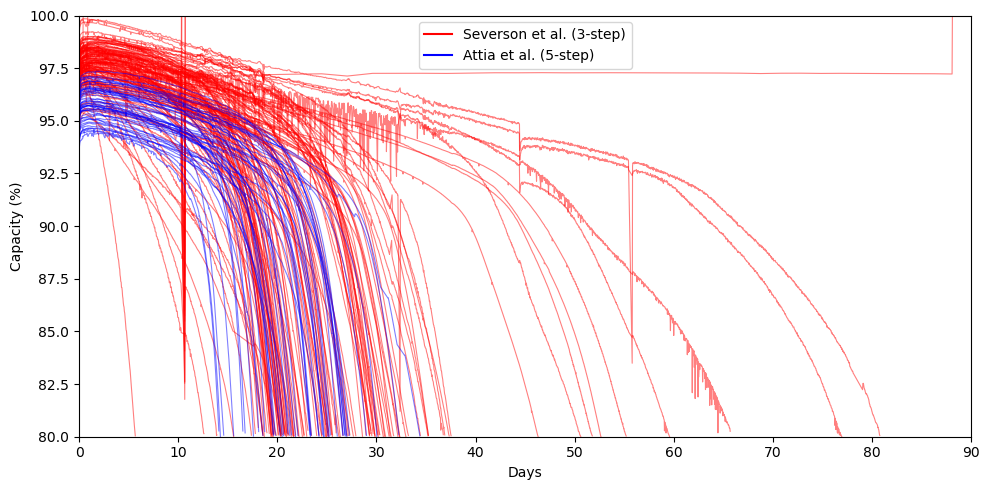

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))

NOMINAL_CAP = 1.1  # Ah

for key in batDict:
    cell    = batDict[key]
    qd      = cell['summary']['QD']
    
    # compute actual cycle durations from raw cycle data
    cycle_durations = []
    for ck in cell['cycles']:
        t = cell['cycles'][ck]['t']
        cycle_durations.append(t[-1] - t[0])
    
    days    = np.cumsum(cycle_durations) / 60 / 24   
    cap_pct = qd / NOMINAL_CAP * 100
    mask    = (cap_pct >= 80) & (len(days) == len(qd))  # safety check
    
    # trim to same length in case cycles and summary differ by 1
    n       = min(len(days), len(qd))
    days    = days[:n]
    cap_pct = cap_pct[:n]
    mask    = cap_pct >= 80
    
    color   = 'blue' if key.startswith('b4') else 'red'
    ax.plot(days[mask], cap_pct[mask], color=color, alpha=0.5, linewidth=0.8)

ax.set_xlabel('Days')
ax.set_ylabel('Capacity (%)')
ax.set_xlim(0, 90)
ax.set_ylim(80, 100)

from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0], [0], color='red',  label='Severson et al. (3-step)'),
    Line2D([0], [0], color='blue', label='Attia et al. (5-step)')
])
plt.tight_layout()
plt.show()

In [27]:
# Top-level keys (cell IDs)
cell_ids = list(batDict.keys())
print(f"Number of cells: {len(cell_ids)}")
print(f"First few IDs: {cell_ids[:5]}")

# Inspect one cell
cell = batDict[cell_ids[0]]
print(f"\nType of cell value: {type(cell)}")

# If it's a dict, show its keys
if isinstance(cell, dict):
    print(f"Keys: {list(cell.keys())}")
    for k, v in cell.items():
        print(f"  {k}: {type(v)} — {str(v)[:100]}")
else:
    print(cell)

Number of cells: 169
First few IDs: ['b1c0', 'b1c1', 'b1c2', 'b1c3', 'b1c4']

Type of cell value: <class 'dict'>
Keys: ['cycle_life', 'charge_policy', 'summary', 'cycles']
  cycle_life: <class 'float'> — 1852.0
  charge_policy: <class 'str'> — 3.6C(80%)-3.6C
  summary: <class 'dict'> — {'IR': array([0.        , 0.01674235, 0.01672431, ..., 0.0181332 , 0.0181233 ,
       0.0181211 ]), 
  cycles: <class 'dict'> — {'0': {'I': array([0, 0], dtype=uint64), 'Qc': array([0, 0], dtype=uint64), 'Qd': array([0, 0], dtyp


In [29]:
# Find one 3-step and one 5-step cell
for cell_id, cell in batDict.items():
    policy = cell['charge_policy']
    if policy.count('C') == 6:  # 5-step has more segments
        print(f"5-step example — {cell_id}: {policy}")
        five_step_id = cell_id
        break

for cell_id, cell in batDict.items():
    policy = cell['charge_policy']
    if policy.count('-') == 1:  # 3-step: one transition
        print(f"3-step example — {cell_id}: {policy}")
        three_step_id = cell_id
        break

# Check what's inside a cycle to understand available signals
cycle = batDict[cell_ids[0]]['cycles']['1']
print(f"\nCycle keys: {list(cycle.keys())}")
for k, v in cycle.items():
    print(f"  {k}: shape={getattr(v, 'shape', 'N/A')}, first values={str(v[:3])}")

3-step example — b1c0: 3.6C(80%)-3.6C

Cycle keys: ['I', 'Qc', 'Qd', 'Qdlin', 'T', 'Tdlin', 'V', 'dQdV', 't']
  I: shape=(1087,), first values=[0.         0.21590753 0.35983085]
  Qc: shape=(1087,), first values=[0.0000000e+00 1.0935055e-06 1.0935055e-06]
  Qd: shape=(1087,), first values=[0. 0. 0.]
  Qdlin: shape=(1000,), first values=[-0.00035743 -0.00031852 -0.00028185]
  T: shape=(1087,), first values=[31.632496 31.632496 31.632496]
  Tdlin: shape=(1000,), first values=[29.58588212 29.58588989 29.58589615]
  V: shape=(1087,), first values=[2.0264158 2.0393877 2.0516596]
  dQdV: shape=(1000,), first values=[-0.01269012 -0.01269012 -0.01269012]
  t: shape=(1087,), first values=[0.         0.00241667 0.00291167]


In [31]:
# Print all unique charge_policy strings to understand formats
policies = set(cell['charge_policy'] for cell in batDict.values())
print(f"Total unique policies: {len(policies)}")
for p in sorted(policies)[:20]:
    print(f"  '{p}'")

Total unique policies: 78
  '1C(4%)-6C'
  '2C(10%)-6C'
  '2C(2%)-5C'
  '2C(7%)-5.5C'
  '3.6-6-5.6-4.755'
  '3.6C(2%)-4.85C'
  '3.6C(22%)-5.5C'
  '3.6C(30%)-6C'
  '3.6C(80%)-3.6C'
  '3.6C(9%)-5C'
  '3.7C(31%)-5.9C-newstructure'
  '4.4-5.6-5.2-4.252'
  '4.4C(24%)-5C'
  '4.4C(47%)-5.5C'
  '4.4C(55%)-6C'
  '4.4C(8%)-4.85C'
  '4.4C(80%)-4.4C'
  '4.65C(19%)-4.85C'
  '4.65C(44%)-5C'
  '4.65C(69%)-6C'


In [33]:
# Find all Attia-style (5-step) policies — they have no 'C(' pattern
attia_policies = [(cid, cell['charge_policy']) 
                  for cid, cell in batDict.items() 
                  if '(' not in cell['charge_policy']]

print(f"Attia-style cells: {len(attia_policies)}")
for cid, p in attia_policies[:5]:
    print(f"  {cid}: '{p}'")

Attia-style cells: 45
  b4c0: '4.8-5.2-5.2-4.16'
  b4c1: '3.6-6-5.6-4.755'
  b4c2: '3.6-6-5.6-4.755'
  b4c3: '8-4.4-4.4-3.94'
  b4c4: '8-6-4.8-3'


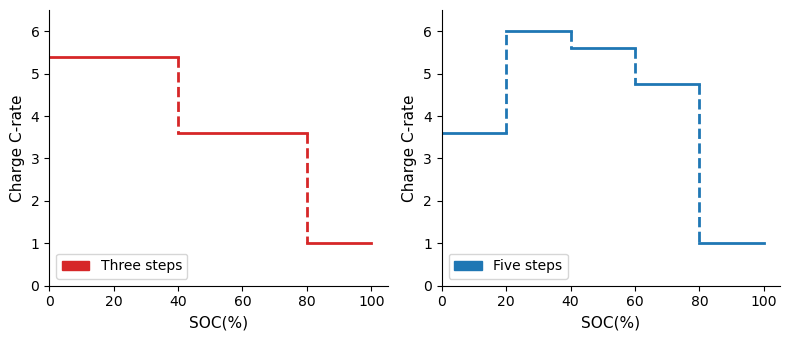

In [38]:
# ── Parse policy strings ──────────────────────────────────────────────────────
import matplotlib.patches as mpatches

def parse_severson(policy):
    """'3.6C(80%)-3.6C'  →  list of (soc_start, soc_end, c_rate)"""
    # Split on '-'
    parts = policy.split('-')
    # First part: rate and breakpoint, e.g. '3.6C(80%)'
    first = parts[0]            # '3.6C(80%)'
    rate1 = float(first.split('C')[0])
    soc_break = float(first.split('(')[1].replace('%)', '')) / 100
    # Second part: rate for middle segment, e.g. '3.6C'
    rate2 = float(parts[1].replace('C', ''))
    # Final segment always 1C from 80–100%
    steps = [
        (0.0,       soc_break, rate1),
        (soc_break, 0.80,      rate2),
        (0.80,      1.00,      1.0),
    ]
    return steps

def parse_attia(policy):
    """'3.6-6-5.6-4.755'  →  list of (soc_start, soc_end, c_rate)
    4 rates across equal 20% bands (0–80%), then 1C from 80–100%"""
    rates = [float(r) for r in policy.split('-')]
    breakpoints = [0.0, 0.20, 0.40, 0.60, 0.80, 1.00]
    steps = [(breakpoints[i], breakpoints[i+1], rates[i]) for i in range(4)]
    steps.append((0.80, 1.00, 1.0))  # final 1C step
    return steps

def get_steps(cell_id):
    policy = batDict[cell_id]['charge_policy']
    if '(' in policy:
        return parse_severson(policy), 'severson'
    else:
        return parse_attia(policy), 'attia'

# ── Pick one exemplary cell of each type ─────────────────────────────────────

# Severson: use b1c9 ('3.6C(80%)-3.6C') — matches paper's 3-step example
severson_id = 'b1c9'

# Attia: use b4c1 ('3.6-6-5.6-4.755') — a clean 5-step cell
attia_id = 'b4c1'

sev_steps, _ = get_steps(severson_id)
att_steps, _ = get_steps(attia_id)

# ── Plot ──────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))

RED  = '#d62728'
BLUE = '#1f77b4'

for ax, steps, color, label, title in [
    (axes[0], sev_steps, RED,  'Three steps', f'Three steps\n({batDict[severson_id]["charge_policy"]})'),
    (axes[1], att_steps, BLUE, 'Five steps',  f'Five steps\n({batDict[attia_id]["charge_policy"]})'),
]:
    for (soc_s, soc_e, rate) in steps:
        soc_pct_s = soc_s * 100
        soc_pct_e = soc_e * 100
        # Horizontal segment
        ax.plot([soc_pct_s, soc_pct_e], [rate, rate], color=color, linewidth=2)
        # Vertical drop to next segment (dashed)
        next_steps = steps[steps.index((soc_s, soc_e, rate)) + 1:] 
        if next_steps:
            next_rate = next_steps[0][2]
            ax.plot([soc_pct_e, soc_pct_e], [rate, next_rate],
                    color=color, linewidth=2, linestyle='--')

    ax.set_xlim(0, 105)
    ax.set_ylim(0, 6.5)
    ax.set_xlabel('SOC(%)', fontsize=11)
    ax.set_ylabel('Charge C-rate', fontsize=11)
    ax.legend(handles=[mpatches.Patch(color=color, label=label)],
              loc='lower left', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('soc_crate_protocols.png', dpi=150, bbox_inches='tight')
plt.show()

eolDays range:  6.4 – 133.5  (paper: 5–80)
eolDays mean:   27.8  (paper: ~26)
avgCrates range: 3.08 – 4.80


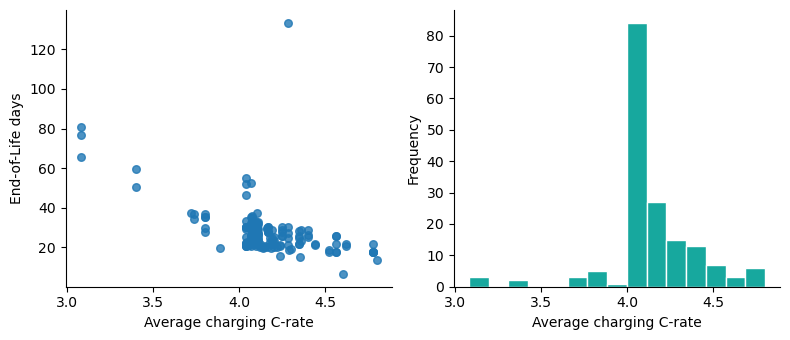

In [48]:
from matplotlib.lines import Line2D

# ── Compute average SOC-weighted C-rate per cell ──────────────────────────────

def computeAvgCrate(cellId):
    steps, _ = get_steps(cellId)
    avgCrate = sum((socE - socS) * rate for socS, socE, rate in steps)
    return avgCrate  # steps already in fraction → weights sum to 1

cellIds  = list(batDict.keys())
avgCrates = np.array([computeAvgCrate(cid) for cid in cellIds])
eolDays   = np.array([batDict[cid]['cycle_life'] for cid in cellIds])

# Check if cycle_life > len(chargetime) for some cells
for cid in cellIds:
    cl  = int(batDict[cid]['cycle_life'])
    ct  = batDict[cid]['summary']['chargetime']
    if cl > len(ct) + 5:
        print(f"{cid}: cycle_life={cl}, len(chargetime)={len(ct)}, diff={cl - len(ct)}")

# cycle_life is in cycles — convert to days using average cycle time
# total minutes per cycle = chargetime + discharge (4C on 1.1Ah → ~16.5 min)
DISCHARGE_MIN = 1.1 / 4 * 60

def cyclesToDays(cellId):
    cycleDurations = []
    for ck in batDict[cellId]['cycles']:
        t = batDict[cellId]['cycles'][ck]['t']
        cycleDurations.append(t[-1] - t[0])
    return np.cumsum(cycleDurations)[-1] / 60 / 24

eolDays = np.array([cyclesToDays(cid) for cid in cellIds])

print(f"eolDays range:  {eolDays.min():.1f} – {eolDays.max():.1f}  (paper: 5–80)")
print(f"eolDays mean:   {eolDays.mean():.1f}  (paper: ~26)")
print(f"avgCrates range: {avgCrates.min():.2f} – {avgCrates.max():.2f}")

# ── Plot 1 & 2 ────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))

axes[0].scatter(avgCrates, eolDays, color='#1f77b4', s=30, alpha=0.8)
axes[0].set_xlabel('Average charging C-rate')
axes[0].set_ylabel('End-of-Life days')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].hist(avgCrates, bins=15, color='#17a89e', edgecolor='white')
axes[1].set_xlabel('Average charging C-rate')
axes[1].set_ylabel('Frequency')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('avgCrate_eol.png', dpi=150, bbox_inches='tight')
plt.show()

In [40]:
# Check a sample of computed avg C-rates vs their raw policy strings
for cid in list(batDict.keys())[::15]:
    policy = batDict[cid]['charge_policy']
    avgCr  = computeAvgCrate(cid)
    print(f"{cid}: '{policy}'  →  avg={avgCr:.3f}C")

b1c0: '3.6C(80%)-3.6C'  →  avg=3.080C
b1c19: '5.4C(70%)-3C'  →  avg=4.280C
b1c35: '7C(30%)-3.6C'  →  avg=4.100C
b2c4: '3.6C(22%)-5.5C'  →  avg=4.182C
b2c24: '4.8C(80%)-4.8C'  →  avg=4.040C
b2c39: '5.6C(58%)-3.5C'  →  avg=4.218C
b3c7: '4.8C(80%)-4.8C-newstructure'  →  avg=4.040C
b3c22: '5.9C(60%)-3.1C-newstructure'  →  avg=4.360C
b3c40: '5.6C(19%)-4.6C-newstructure'  →  avg=4.070C
b4c11: '4.8-5.2-5.2-4.16'  →  avg=4.072C
b4c26: '8-7-5.2-2.68'  →  avg=4.776C
b4c41: '5.2-5.2-4.8-4.16'  →  avg=4.072C


In [41]:
# Compare cycle_life vs len(summary arrays) — if they match it's cycles, not days
for cid in ['b1c0', 'b1c9', 'b4c1']:
    cl  = batDict[cid]['cycle_life']
    qd  = batDict[cid]['summary']['QD']
    print(f"{cid}: cycle_life={cl:.0f}, len(QD)={len(qd)}")

# Also check the range of eolDays vs paper's reported 5-80 days
print(f"\neolDays range: {eolDays.min():.1f} – {eolDays.max():.1f}")
print(f"avgCrates range: {avgCrates.min():.2f} – {avgCrates.max():.2f}")

b1c0: cycle_life=1852, len(QD)=1851
b1c9: cycle_life=1054, len(QD)=1053
b4c1: cycle_life=761, len(QD)=862

eolDays range: 3.0 – 47.5
avgCrates range: 3.08 – 4.80


In [42]:
# Check the actual chargetime values — minutes or seconds?
cid = 'b1c0'
ct  = batDict[cid]['summary']['chargetime']
print(f"chargetime first 5 values: {ct[:5]}")
print(f"chargetime mean: {ct.mean():.2f}")

# Also: total days using cumsum (consistent with capacity plot)
def cyclesToDaysCumsum(cellId):
    ct            = batDict[cellId]['summary']['chargetime']
    dischargeMins = 1.1 / 4 * 60
    cycleMins     = ct + dischargeMins
    return np.cumsum(cycleMins)[-1] / 60 / 24

print(f"\nb1c0 days (cumsum): {cyclesToDaysCumsum('b1c0'):.1f}")
print(f"b4c1 days (cumsum): {cyclesToDaysCumsum('b4c1'):.1f}")
print(f"paper reports avg ~26 days")

chargetime first 5 values: [ 0.         13.34125    13.42577667 13.42516667 13.34144167]
chargetime mean: 13.52

b1c0 days (cumsum): 38.6
b4c1 days (cumsum): 16.8
paper reports avg ~26 days


In [46]:
# Find the longest-lived cells by cumsum days
daysList = [(cid, cyclesToDays(cid)) for cid in cellIds]
daysList.sort(key=lambda x: -x[1])

print("Top 10 longest-lived cells:")
for cid, days in daysList[:10]:
    cl     = batDict[cid]['cycle_life']
    policy = batDict[cid]['charge_policy']
    ct     = batDict[cid]['summary']['chargetime']
    print(f"  {cid}: {days:.1f} days, {cl:.0f} cycles, mean_ct={ct.mean():.1f} min, policy='{policy}'")

Top 10 longest-lived cells:
  b1c2: 47.5 days, 2237 cycles, mean_ct=14.1 min, policy='3.6C(80%)-3.6C'
  b1c1: 45.0 days, 2160 cycles, mean_ct=13.5 min, policy='3.6C(80%)-3.6C'
  b1c0: 38.6 days, 1852 cycles, mean_ct=13.5 min, policy='3.6C(80%)-3.6C'
  b3c38: 35.8 days, 1935 cycles, mean_ct=10.1 min, policy='5C(67%)-4C-newstructure'
  b3c7: 35.3 days, 1836 cycles, mean_ct=11.2 min, policy='4.8C(80%)-4.8C-newstructure'
  b3c45: 34.6 days, 1801 cycles, mean_ct=11.1 min, policy='4.8C(80%)-4.8C-newstructure'
  b1c4: 34.1 days, 1709 cycles, mean_ct=12.2 min, policy='4C(80%)-4C'
  b3c16: 31.4 days, 1638 cycles, mean_ct=11.1 min, policy='4.8C(80%)-4.8C-newstructure'
  b1c3: 28.8 days, 1434 cycles, mean_ct=12.4 min, policy='4C(80%)-4C'
  b3c17: 24.3 days, 1315 cycles, mean_ct=10.2 min, policy='5.3C(54%)-4C-newstructure'


In [47]:
def cyclesToDays(cellId):
    cycleDurations = []
    for ck in batDict[cellId]['cycles']:
        t = batDict[cellId]['cycles'][ck]['t']
        cycleDurations.append(t[-1] - t[0])
    return np.cumsum(cycleDurations)[-1] / 60 / 24

eolDays = np.array([cyclesToDays(cid) for cid in cellIds])

print(f"eolDays range: {eolDays.min():.1f} – {eolDays.max():.1f}  (paper: 5–80)")
print(f"eolDays mean:  {eolDays.mean():.1f}  (paper: ~26)")

eolDays range: 6.4 – 133.5  (paper: 5–80)
eolDays mean:  27.8  (paper: ~26)


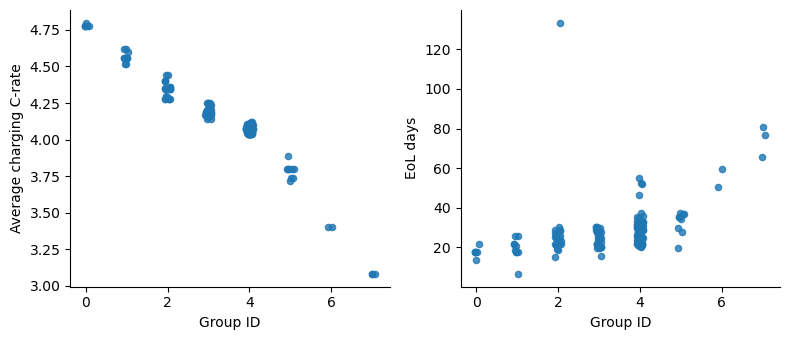

In [51]:
from sklearn.cluster import KMeans

# ── Cluster into 8 groups by average C-rate ───────────────────────────────────
N_GROUPS = 8

avgCratesReshaped = avgCrates.reshape(-1, 1)
kmeans            = KMeans(n_clusters=N_GROUPS, random_state=42, n_init=10)
groupIds          = kmeans.fit_predict(avgCratesReshaped)

# Sort group labels by ascending mean C-rate (so group 0 = lowest C-rate)
groupMeans   = [avgCrates[groupIds == g].mean() for g in range(N_GROUPS)]
sortedGroups = np.argsort(groupMeans)[::-1]  # add [::-1]
remapGroup   = {old: new for new, old in enumerate(sortedGroups)}
groupIds     = np.array([remapGroup[g] for g in groupIds])

# ── Plot 3 & 4 ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))

for gid in range(N_GROUPS):
    mask     = groupIds == gid
    gCrates  = avgCrates[mask]
    gEolDays = eolDays[mask]

    # jitter x slightly so overlapping points are visible
    jitter = np.random.uniform(-0.08, 0.08, size=mask.sum())

    axes[0].scatter(np.full(mask.sum(), gid) + jitter, gCrates,
                    color='#1f77b4', s=20, alpha=0.8)
    axes[1].scatter(np.full(mask.sum(), gid) + jitter, gEolDays,
                    color='#1f77b4', s=20, alpha=0.8)

axes[0].set_xlabel('Group ID')
axes[0].set_ylabel('Average charging C-rate')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].set_xlabel('Group ID')
axes[1].set_ylabel('EoL days')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('groupCrate_eol.png', dpi=150, bbox_inches='tight')
plt.show()

In [52]:
# Check group sizes and mean C-rates
for g in range(N_GROUPS):
    mask = groupIds == g
    print(f"Group {g}: n={mask.sum():3d}, "
          f"mean C-rate={avgCrates[mask].mean():.3f}, "
          f"mean EoL={eolDays[mask].mean():.1f} days")

Group 0: n=  6, mean C-rate=4.780, mean EoL=17.6 days
Group 1: n= 10, mean C-rate=4.568, mean EoL=19.4 days
Group 2: n= 20, mean C-rate=4.344, mean EoL=29.3 days
Group 3: n= 32, mean C-rate=4.195, mean EoL=24.2 days
Group 4: n= 87, mean C-rate=4.074, mean EoL=27.8 days
Group 5: n=  9, mean C-rate=3.788, mean EoL=32.6 days
Group 6: n=  2, mean C-rate=3.400, mean EoL=55.1 days
Group 7: n=  3, mean C-rate=3.080, mean EoL=74.5 days


In [53]:
# Try a few random states and pick the one with most balanced groups
for seed in [0, 7, 13, 21, 42, 99]:
    km  = KMeans(n_clusters=N_GROUPS, random_state=seed, n_init=10)
    gid = km.fit_predict(avgCratesReshaped)
    sizes = np.bincount(gid)
    print(f"seed={seed:3d}: group sizes={sorted(sizes, reverse=True)}, max={sizes.max()}")

seed=  0: group sizes=[87, 32, 20, 10, 9, 6, 3, 2], max=87
seed=  7: group sizes=[87, 32, 20, 10, 9, 6, 3, 2], max=87
seed= 13: group sizes=[87, 32, 20, 10, 9, 6, 3, 2], max=87
seed= 21: group sizes=[87, 32, 20, 10, 9, 6, 3, 2], max=87
seed= 42: group sizes=[87, 32, 20, 10, 9, 6, 3, 2], max=87
seed= 99: group sizes=[87, 32, 20, 10, 9, 6, 3, 2], max=87
